**SPDX-License-Identifier: GPL-3.0**  
**Copyright (c) 2025**  
**Authors: Laura Rinaldi**

\begin{aligned}
     \mu \Delta \mathbf{u} - \nabla p  &= f \quad \forall \mathbf{x} \in \Omega
\end{aligned}



\begin{aligned}
     \Omega = [0,1]^2  \\
\end{aligned}

for the velocity $\mathbf{u}$ and the pressure $p$. Especially:


-$\mu$ is the viscosity


In [1]:
import torch, math, os, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import seaborn as sns
from datetime import datetime
import pickle

from torch import nn
from torch.utils.data import random_split, DataLoader
import torch.optim as optim

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
from abc import ABC, abstractmethod

from sympy.utilities.iterables import multiset_permutations
from itertools import product

import copy

In [2]:
# packages needed:
# numpy, torch, sympy
# for graphical content: matplotlib, scipy, seaborn

# nb works with versions:
# python: 3.11.10
# numpy: 1.26.4
# torch: 2.5.1
# sympy: 1.13.1
# matplotlib: 3.9.2
# scipy: 1.14.1
# seaborn: 0.13.2

#python
import sys
print(f"{sys.version = }")
# numpy
import numpy
print(f"{numpy.__version__ = }")
# torch
print(f"{torch.__version__ = }")
# sympy
import sympy
print(f"{sympy.__version__ = }")
# matplotlib
import matplotlib
print(f"{matplotlib.__version__ = }")
#scipy
import scipy
print(f"{scipy.__version__ = }")
# seaborn
import seaborn
print(f"{seaborn.__version__ = }")

sys.version = '3.11.11 (main, Dec 11 2024, 16:28:39) [GCC 11.2.0]'
numpy.__version__ = '2.2.4'
torch.__version__ = '2.5.1'
sympy.__version__ = '1.13.3'
matplotlib.__version__ = '3.10.0'
scipy.__version__ = '1.15.2'
seaborn.__version__ = '0.13.2'


In [3]:
# GPU check
print(f"{torch.cuda.is_available() = }")
#print(f"{torch.cuda.device_count() = }")
#print(f"{torch.cuda.current_device() = }")
#current_device = torch.cuda.current_device()
#print(f"{torch.cuda.device(current_device) = }")
#print(f"{torch.cuda.get_device_name(current_device) = }")
#print("\n")
#
## to check NVIDIA's CUDA compiler (nvcc) version
#!nvcc --version

torch.cuda.is_available() = False


# Error and Loss Function

In [4]:
# Used for computing the error in the test dataset
class VarMiONLossTime(torch.nn.Module):
    def __init__(self, n_grid_pts, n_bry_pts, times, J, tdim):
        super().__init__()
        self.n_grid_pts = n_grid_pts
        self.n_bry_pts = n_bry_pts
        self.J = J
        self.tdim = tdim
                
        self.T = times[-1] - times[0]
        self.n_times = len(times)   -1    
        self.device =  'cpu'
       
        self.weights =self.quadrature_time(N=self.tdim+1, T=self.T,  m=self.n_times, n=self.n_grid_pts-1)
    def quadrature_time(self, N, T, m, n):
        # N = space dimension of [0,T] x [0,1]^(N-1)
        # t = 0 initial time
        # T = final time
        # m = #subintervals in [0,T]
        # n = #subintervals in [0,1]
    
        
        def vertices(N): 
            return list(product((0, 1), repeat=N))
    
        def create_mesh(N, t_vec, x_vec):
            x_mesh = np.array(list(product(x_vec, repeat=N-1)))
            return [np.append(t,x) for t in t_vec for x in x_mesh]
        
        
        V = np.ones((N,N+1))
        V = np.tril(V)
    
        M = vertices(N)
        M = np.array(M).T
        x = np.zeros(2**N)
    
        for sigma in multiset_permutations(np.arange(N)):
            V_sigma = V.copy()
            V_sigma = V[sigma,:]
            for i in range(N+1):
                tmp = np.all(V_sigma[:,i] == M.T, axis = 1)
                j = np.where(tmp)[0][0]
                x[j] += 1
            #endfor
        #endfor
    
        t_vec = np.arange(0,m+1)
        x_vec = np.arange(0,n+1)
        points = np.array(create_mesh(N, t_vec, x_vec)).T
    
        num_points = (m+1)*((n+1)**(N-1))
        y = np.zeros(num_points)


        for i in range(m):
            for valori in product(np.arange(0,n), repeat=N-1):
                M_tmp = M.copy()
                M_tmp[0,:] += i
                for j in range(1,N):
                    M_tmp[j,:] += valori[j-1]
                #endfor
                
                for k in range(2**N):
                    tmp = np.all(M_tmp[:,k] == points.T, axis = 1)
                    indice_vertice = np.where(tmp)[0][0]
                    y[indice_vertice] += x[k]
                #endfor
            #endfor
        #endfor
        
        num_simplessi = math.factorial(N) * m * n**(N-1)
        c = T / ((N+1) * num_simplessi)

        # weights w
        w = c*y        
        w = w[(n+1)**(N-1):]
        
        return w

    def forward(self, input, target):
        W_p = torch.tile((self.weights), (self.J,)).to(self.device)        
        W_v = torch.repeat_interleave(W_p, repeats=2, dim = 0)
        
        W =torch.cat((torch.repeat_interleave(W_p, repeats=2), W_p), dim = 0)
        diff = target[:,:,:(self.n_grid_pts)**self.tdim*3] - input[:,:,:(self.n_grid_pts)**self.tdim*3]
        return  torch.sum(diff.view(-1)**2)*0.05*0.4*2.2/(self.J*20*50*10)    

In [5]:
# loss function
class VarMiONLossTimeBry(torch.nn.Module):
    def __init__(self, n_grid_pts, n_bry_pts, times, J, tdim, lam=0):
        super().__init__()
        self.n_grid_pts = n_grid_pts
        self.n_bry_pts = n_bry_pts
        self.J = J
        self.tdim = tdim
        self.lam = lam
                
        self.T = times[-1] - times[0]
        self.n_times = len(times)  -1     
        self.device = 'cpu' 
        self.weights =self.quadrature_time(N=self.tdim+1, T=self.T, m=self.n_times, n=self.n_grid_pts-1)
    def quadrature_time(self, N, T, m, n):
        # N = space dimension of [0,T] x [0,1]^(N-1)
        # t = 0 initial time
        # T = final time
        # m = #subintervals in [0,T]
        # n = #subintervals in [0,1]
    
        def vertices(N): 
            return list(product((0, 1), repeat=N))
    
        def create_mesh(N, t_vec, x_vec):
            x_mesh = np.array(list(product(x_vec, repeat=N-1)))
            return [np.append(t,x) for t in t_vec for x in x_mesh]
        
        
        V = np.ones((N,N+1))
        V = np.tril(V)
    
        M = vertices(N)
        M = np.array(M).T
        x = np.zeros(2**N)
    
        for sigma in multiset_permutations(np.arange(N)):
            V_sigma = V.copy()
            V_sigma = V[sigma,:]
            for i in range(N+1):
                tmp = np.all(V_sigma[:,i] == M.T, axis = 1)
                j = np.where(tmp)[0][0]
                x[j] += 1
            #endfor
        #endfor
    
        t_vec = np.arange(0,m+1)
        x_vec = np.arange(0,n+1)
        points = np.array(create_mesh(N, t_vec, x_vec)).T
    
        num_points = (m+1)*((n+1)**(N-1))
        y = np.zeros(num_points)


        for i in range(m):
            for valori in product(np.arange(0,n), repeat=N-1):
                M_tmp = M.copy()
                M_tmp[0,:] += i
                for j in range(1,N):
                    M_tmp[j,:] += valori[j-1]
                #endfor
                
                for k in range(2**N):
                    tmp = np.all(M_tmp[:,k] == points.T, axis = 1)
                    indice_vertice = np.where(tmp)[0][0]
                    y[indice_vertice] += x[k]
                #endfor
            #endfor
        #endfor
        
        num_simplessi = math.factorial(N) * m * n**(N-1)
        c = T / ((N+1) * num_simplessi)

        # weights w
        w = c*y
        
        w = w[(n+1)**(N-1):]
        return w

    def forward(self, input, target):
        #print("input, target: ", input.shape, target.shape)
        W_p = torch.tile((self.weights), (self.J,)).to(self.device)
        W_v = torch.repeat_interleave(W_p, repeats=2, dim = 0)

        
        W =torch.cat((torch.repeat_interleave(W_p, repeats=2), W_p), dim = 0)

        grid_diff = target[:,:,:(self.n_grid_pts)**self.tdim*3] - input[:,:,:(self.n_grid_pts)**self.tdim*3]
        bry_diff = target[:,:,(self.n_grid_pts)**self.tdim*3:] - input[:,:,(self.n_grid_pts)**self.tdim*3:]

        if self.n_bry_pts==0:
            diff = target[:,:,:(self.n_grid_pts)**self.tdim*3] - input[:,:,:(self.n_grid_pts)**self.tdim*3]
            return  torch.sum(diff.view(-1)**2)*0.05*0.4*2.2/(self.J*20*50*10)    
        
        else:
            grid_diff = target[:,:(self.n_grid_pts)**self.tdim*3] - input[:,:(self.n_grid_pts)**self.tdim*3]
            bry_diff = target[:,(self.n_grid_pts)**self.tdim*3:] - input[:,(self.n_grid_pts)**self.tdim*3:]
            return (torch.sum(grid_diff.view(-1)**2)/grid_diff.view(-1).numel() + self.lam*torch.sum(bry_diff.view(-1)**2)/bry_diff.view(-1).numel())/self.J

                
                

# Customized Dataset Class

In [6]:
class dataset_heat_eq_robin(torch.utils.data.Dataset):
    def __init__(self, num_pdes, data_dir):
        super().__init__()
                        
        # num_pdes: integer equal to the number of instances of the pde to be considered
        # data_dir: path of the directory containing the dataset
        
        
        with open(data_dir + '/eval_pts', 'rb') as file:
            self.param_pts = np.load(file) # coords of the points used to sample the parameters
            self.param_bry_pts = np.load(file) # coords of the points used to sample the parameters defined on the boundary
            self.temp_pts = np.load(file) # coords of the points used to sample the temperature
            self.times = np.load(file)
            self.times_train = np.load(file) # array of the times considered in the dataset (includes t=0)
            self.nb = np.load(file) # if not zero: number of points on the boundary (apart from the ones in temp_pts) used to sample the temperature

        
        self.num_pdes = num_pdes
        self.n_param_pts = self.param_pts.shape[0]
        self.n_param_bry_pts = self.param_bry_pts.shape[0]
        self.n_temp_pts = self.temp_pts.shape[0]
        self.n_times = len(self.times)
        
        self.tdim = self.temp_pts.shape[1]
             
        self.data = dict(###L
            mu = np.zeros(shape = (self.num_pdes), dtype = np.float32),
            ff = np.zeros(shape = (self.num_pdes), dtype = np.float32),
            solution = np.zeros(shape = (self.num_pdes, self.n_times-1,   self.n_temp_pts*2), dtype = np.float32),
            solution_pressure = np.zeros(shape = (self.num_pdes,  self.n_times-1,  self.n_temp_pts), dtype = np.float32),
            u0 = np.zeros(shape = (self.num_pdes, self.n_times-1, self.n_temp_pts*2), dtype = np.float32),
            p0 = np.zeros(shape = (self.num_pdes, self.n_times-1, self.n_temp_pts), dtype = np.float32),
        )
        
        self.dir_record = lambda t: f"{data_dir}/record_{t}.npy"
       
        self.check_files_exist()
                   
        for i in range(self.num_pdes):
            self.load_data(i)
        #endfor
                
        self.data = {k: torch.tensor(v, device='cpu', dtype=torch.float32) for k, v in self.data.items()}
        self.temp_pts = torch.tensor(self.temp_pts, device='cpu', dtype=torch.float32)
        self.times = torch.tensor(self.times, device='cpu', dtype=torch.float32)
        
        times_tensor = self.times[1:].view(self.n_times-1, 1, 1).expand(-1, self.n_temp_pts, 1) # size: (n_times-1,n_eval,1)
        points_tensor = self.temp_pts.unsqueeze(0).expand(self.n_times-1, -1, -1) # size: (n_times-1, n_eval, d)        
        self.nodes_tx = torch.cat((times_tensor, points_tensor), dim=-1) # size: (n_times-1, n_eval, 1+d)               
        
        print("Dataset loaded")
                       
    def __len__(self):
        return self.num_pdes
  
    def load_data(self, i: int) -> None:
        #print("i = ", i)
        with open(self.dir_record(i), 'rb') as file:
            self.data["mu"][i] = np.load(file)       
            self.data["ff"][i] = np.load(file)
            tmp0 = np.load(file)
            
            tmp1= tmp0.reshape((21, 325, 3))
            tmp = tmp1[:, :, :2].reshape((21, 325*2))

            tmp_pressure = np.load(file)
            self.data["u0"][i,:] = tmp[:-1,:]
            self.data["solution"][i,:,:] = tmp[1:,:]
            
            self.data["p0"][i,:] = tmp_pressure[:-1,:]
            self.data["solution_pressure"][i,:,:] = tmp_pressure[1:,:]
        
    def check_files_exist(self) -> bool:
        for i in range(self.num_pdes):
            if not os.path.exists(self.dir_record(i)):
                print(f"check {i}: False", )
                return False
        print("Dataset files found...")
        return True

    def __getitem__(self, idx):
        
        input_tx = self.nodes_tx 
        input_mu = self.data['mu'][idx]
        input_f = self.data['ff'][idx] 
        
        if self.nb==0:
            input_u0 = self.data['u0'][idx,:,:]
        else:
            input_u0 = self.data['u0'][idx,:,:-self.nb]
            
        if self.nb==0:
            input_p0 = self.data['p0'][idx,:,:]
        else:
            input_p0 = self.data['p0'][idx,:,:-self.nb]
        
        output_vel = self.data['solution'][idx,:,:]
        output_pressure = self.data['solution_pressure'][idx,:,:]
        output = torch.cat((output_vel , output_pressure), dim=1) 

        
        return input_tx, input_mu, input_f, output

# Neural Network Model

In [7]:
class HeatEquationVarMiONRobin(nn.Module):
    def __init__(self):
        super().__init__()
            
        self.theta_branch=nn.Sequential( nn.Unflatten(1, (1, 10, 10)), 
                                        nn.ConvTranspose2d(in_channels=1, out_channels=8, kernel_size=4, stride=1), 
                                        nn.ReLU(), 
                                        nn.BatchNorm2d(8), 
                                        nn.ConvTranspose2d(in_channels=8, out_channels=16, kernel_size=4, stride=1), 
                                        nn.ReLU(), 
                                        nn.BatchNorm2d(16), 
                                        nn.ConvTranspose2d(in_channels=16,out_channels= 8, kernel_size=2, stride=2), 
                                        nn.ReLU(), 
                                        nn.BatchNorm2d(8), 
                                        nn.ConvTranspose2d(in_channels=8, out_channels=1, kernel_size=2, stride=2), 
                                        nn.ReLU(), 
                                        nn.Flatten(), 
                                        nn.Unflatten(1,(64,64)) )



                  
        self.theta_branch_2 =  copy.deepcopy(self.theta_branch)   
        self.theta_branch_3 =  copy.deepcopy(self.theta_branch)
        self.theta_branch_4 =  copy.deepcopy(self.theta_branch)

        self.f_branch =  nn.Sequential(
            nn.Linear(in_features=100,  out_features=128)
        )
                 
        self.mu_branch = nn.Sequential(             
            nn.Linear(in_features=100, out_features=100),
            
        ) 
           
          
        self.mu_branch_2 =  copy.deepcopy(self.mu_branch) 
        self.mu_branch_3 =  copy.deepcopy(self.mu_branch) 
        self.mu_branch_4 =  copy.deepcopy(self.mu_branch) 
                  
 
        self.trunk_branch = nn.Sequential(
            nn.Linear(in_features=3, out_features=100),
            nn.ReLU(),
            nn.Linear(in_features=100, out_features=100),
            nn.ReLU(),
            nn.Linear(in_features=100, out_features=100),
            nn.ReLU(),
            nn.Linear(in_features=100, out_features=100),
            nn.ReLU(),
            nn.Linear(in_features=100, out_features=128)
        )
        
        self.trunk_branch_3 =  copy.deepcopy(self.trunk_branch) 
         
        self.trunk_branch_2 =  nn.Sequential(
            nn.Linear(in_features=3, out_features=100),
            nn.ReLU(),
            nn.Linear(in_features=100, out_features=100),
            nn.ReLU(),
            nn.Linear(in_features=100, out_features=100),
            nn.ReLU(),
            nn.Linear(in_features=100, out_features=100),
            nn.ReLU(),
            nn.Linear(in_features=100, out_features=128)
        )
        
    def forward(self, inputs,  outputs=None, mode=None):
        input_tx, input_mu, input_f = inputs #
        def forward_inside_0(inputs): 
                input_tx, input_mu, input_f = inputs   

                
                one=torch.ones(input_mu.shape).to("cpu")

                f_branch =  (800*input_f.view(-1,1) ).expand(-1,100)
                f_vec_branch = self.f_branch(f_branch).unsqueeze(-1)
            

            
                input_1 = torch.ones(input_mu.shape).to("cpu")
                input_0 = torch.zeros(input_mu.shape).to("cpu")
                
                
                sum_1 = self.mu_branch((one/input_mu).view(-1,1).expand(-1,100))  
                sum_2 = self.mu_branch_2((one/input_mu).view(-1,1).expand(-1,100))  
                sum_3 = self.mu_branch_3((one/input_mu).view(-1,1).expand(-1,100))  
                sum_4 = self.mu_branch_4((one/input_mu).view(-1,1).expand(-1,100))  
#               
                out1 = self.theta_branch(sum_1)  
                out2 = self.theta_branch_2(sum_2)
                out3 = self.theta_branch_3(sum_3)
                out4 = self.theta_branch_4(sum_4)

                top = torch.cat((out1, out2), dim=2)    
                bottom = torch.cat((out3, out4), dim=2)

                output_128 = torch.cat((top, bottom), dim=1)
                
                
                trunk =self.trunk_branch(  input_tx)
                trunk_2 =self.trunk_branch_2(  input_tx)
                trunk_3 =self.trunk_branch_3(  input_tx)
             

                combined = torch.stack((trunk, trunk_3), dim=3) 
                interleaved = combined.view(trunk.size(0), trunk.size(1), trunk.size(2)*2, trunk.size(3))  # -> [8, 200, 64]
 
                trunk= torch.cat((interleaved, trunk_2), dim=2)
                trunk = trunk.permute(0,1,3,2)

                sum_o =  f_vec_branch  

                output = torch.matmul(output_128, sum_o )
                output = output.permute(0,2,1)
                output = output.unsqueeze(0)
                output = output.permute(1, 0,2,3)
                output = output  
                output = torch.matmul(output, trunk)
                output = output.permute(0,1, 3, 2)
                output = output.squeeze(-1)

                output = output 
                return output

        output_new =forward_inside_0(( input_tx, input_mu, input_f  ))
        return output_new
        
        

# VarMiON Class for training/validation/testing of a Variationally Mimetic Operator Network

In [8]:
class VarMiON():
    def __init__(self, dataset):
        
        self.dataset = dataset
        self.tdim = dataset.tdim        
        self.device =  'cpu'        
        print(f"Device = {self.device}")       
        
        self.n_grid_pts = int(np.sqrt(self.dataset.n_temp_pts - self.dataset.nb))

        
        self.loss_err = VarMiONLossTime(n_grid_pts = self.n_grid_pts, n_bry_pts = self.dataset.nb, times=self.dataset.times, J=1, tdim=self.tdim)
           
        self.lam = 0
        self.epoch = 0
           
        # compute the size of the dataset and of the training, validation and testing sub-datasets
        train_fraction = 0.8
        val_fraction = 0.1
        test_fraction = 0.1

        n_total = len(self.dataset)
        n_train = int(n_total*train_fraction)
        n_val = int(n_total*val_fraction)
        n_test = int(n_total*test_fraction)      
        
        print(f"Number of PDE instances in the dataset: {n_total}") 
        print(f"Used for the training: {n_train}")
        print(f"Used for the validation: {n_val}")
        print(f"Used for the testing: {n_test}") 
                
        
        generator = torch.Generator().manual_seed(42)
        self.train_data, self.val_data, self.test_data = random_split(self.dataset, [train_fraction,val_fraction,test_fraction], generator=generator)
            
        # these tensors will contain the value of the loss function at each epoch
        self.losses = ...
        self.val_losses = ...   
        
        self.best_epoch = 0       
        self.test_error_best = torch.zeros(n_test).to(self.device) # contains relative error
        self.test_abs_error_best = torch.zeros(n_test).to(self.device) # contains absolute error     
    
    def train_step_fn(self, X, y):
        self.model.train()
                
        pred = self.model(X, outputs= y, mode='train')  
        loss = self.loss_fn(pred, y)
        
        loss.backward()
        self.optimizer.step()
        self.optimizer.zero_grad()
        
        return loss.item()
    
    

    def val_step_fn(self, X, y):
        self.model.eval()
        
        pred = self.model(X, outputs= y, mode='val')                    
                 
        loss = self.loss_fn(pred, y)
          
        return loss.item()

    
    
    def test_step_fn(self, X, y):
        self.model.eval()
        
        pred = self.model(X, outputs= y, mode='test' )                
        loss = self.test_loss_fn(pred, y)
        
        
        # compute relative error
        y_quad = self.loss_err(y, torch.zeros(y.shape).to(self.device))
        diff_quad = self.loss_err(pred, y)
        self.test_error_best[self.counter_test] = torch.sqrt(diff_quad/y_quad)
        self.test_abs_error_best[self.counter_test] = torch.sqrt(diff_quad)
        
        self.counter_test += 1
                
        return loss.item()

    def _mini_batch(self, mode):
        if mode=="validation":
            data_loader = self.val_loader
            step_fn = self.val_step_fn
        elif mode=="training":
            data_loader = self.train_loader
            step_fn = self.train_step_fn
        elif mode=="testing":
            data_loader = self.test_loader
            step_fn = self.test_step_fn
        #endif

        mini_batch_losses = []
        
        
        for j, my_data in enumerate(data_loader): 
            X = [elem.to(self.device) for elem in my_data[:-1]]
            y = my_data[-1].to(self.device)    
            
            mini_batch_loss = step_fn(X,y)
            mini_batch_losses.append(mini_batch_loss)
        #endfor
                                     
        loss = np.mean(mini_batch_losses)
        return loss
    
    
    def _train(self, n_epochs, seed=1):

        for epoch in range(n_epochs):
            print(f"Epoch {epoch+1}/{n_epochs}")
            
            start_epoch = time.time()            
            self.epoch = epoch
            
            # training
            loss = self._mini_batch(mode="training")
            self.losses[epoch] = loss                                   

            with torch.no_grad():                
                # validation
                val_loss = self._mini_batch(mode="validation")
                self.val_losses[epoch] = val_loss
                
                if val_loss < self.val_loss_min:
                    self.best_epoch = epoch
                    self.val_loss_min = val_loss
                    torch.save(self.model.state_dict(), 'model_weights_best.pth')
                #endif
                                              
            if self.verbose:
                print(f"{'Loss':<15}= {val_loss:.18f}")
                print(f"{'Lowest loss':<15}= {self.val_loss_min:.18f} at epoch {self.best_epoch+1}")
                print(f"Elapsed time = {(time.time() - start_epoch):.2f} s")
                print()                
            #endif
            
                      
    def training_validation(self, n_epochs, pdes_per_batch=1, verbose=False):
        
        start_timer = time.time()
                        
        self.pdes_per_batch = pdes_per_batch
        self.verbose = verbose
              
        self.train_loader = DataLoader(self.train_data, batch_size=self.pdes_per_batch, shuffle=True)
        self.val_loader = DataLoader(self.val_data, batch_size=self.pdes_per_batch)
        
               
        # these tensors will contain the value of the loss function at each epoch
        self.losses = torch.zeros(n_epochs).to(self.device)
        self.val_losses = torch.zeros(n_epochs).to(self.device)
        self.val_loss_min = float('inf')                   
                      
        self.loss_fn =  VarMiONLossTimeBry(n_grid_pts = self.n_grid_pts, n_bry_pts = self.dataset.nb,  times=self.dataset.times, J=self.pdes_per_batch, tdim = self.tdim, lam = self.lam)
        
                    
        # create the model and send it to device
        self.model = HeatEquationVarMiONRobin()
        self.model.to(self.device)
                
        # compute total number of parameters # TODO put it in the test_script
        total_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        print("Number of parameters of the NN: ", total_params, "\n")
        
        # define the optimizer
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=1.e-4) 

        # training
        self._train(n_epochs)
                        
        self.losses = self.losses.detach().cpu().numpy()
        self.val_losses = self.val_losses.detach().cpu().numpy()

        print(f"\n Total elapsed time: {(time.time() - start_timer):.2f} s")
        
        
        
        
        
    def plot_losses(self, save_dir = None):
                                     
        
        fig, ax = plt.subplots(1,2, figsize=(16,8))
        ax[0].plot(varmion.losses, '-r', label='Training')
        ax[0].plot(varmion.val_losses, '-b', label='Validation')
        ax[0].set_title("Training and Validation Loss")
        ax[0].set_xlabel("Epoch")
        ax[0].set_ylabel("Loss")
        ax[0].legend()
        ax[0].grid()
                      
        ax[1].semilogy(varmion.losses, '-r', label='Training')
        ax[1].semilogy(varmion.val_losses, '-b', label='Validation')
        ax[1].set_title("Training and Validation Loss")
        ax[1].set_xlabel("Epoch")
        ax[1].set_ylabel("Loss")
        ax[1].legend()
        ax[1].grid()

                      

        if save_dir is not None:
            fig.savefig(save_dir + '/losses.png', bbox_inches='tight')
            np.save(save_dir + '/training_losses', self.losses)
            np.save(save_dir + '/val_losses', self.val_losses)
        
              
    def testing(self, plots = True, save_dir = None):
            
        # create the model and send it to device
        self.model = HeatEquationVarMiONRobin()
        self.model.to(self.device)
        
        # load the best model's weights
        self.model.load_state_dict(torch.load('model_weights_best.pth', weights_only=True))
        self.model.eval()
                
        self.test_loader = DataLoader(self.test_data, batch_size=1)
        self.test_loss_fn = VarMiONLossTimeBry(n_grid_pts = self.n_grid_pts, n_bry_pts = self.dataset.nb, times=self.dataset.times, J=1, tdim = self.tdim)
       
        with torch.no_grad():
            
            self.counter_test = 0
            self.test_loss_best = self._mini_batch(mode="testing") # it computes self.test_error_best too # da mod
            
        self.test_error_best_numpy = self.test_error_best.detach().cpu().numpy()
        self.test_abs_error_best_numpy = self.test_abs_error_best.detach().cpu().numpy()
        
        
        if plots:
            err_rel = self.test_error_best_numpy*100
            print("Relative error on the test dataset")                  
            print(f"Mean: {np.mean(self.test_error_best_numpy)*100:.2f} %")
            print(f"std:  {np.std(self.test_error_best_numpy)*100:.2f} %")
            print()
                
            density = stats.gaussian_kde(err_rel)
            x = np.linspace(min(err_rel), max(err_rel), 100)
                            
            fig1, ax1 = plt.subplots()
            ax1.plot(x, density(x), color='C0')
            ax1.hist(err_rel, bins=15, density=True, color='C0', alpha=0.8)
            ax1.set_title(r'Probability density of the relative $L_2$ error - testing dataset')
            ax1.set_xlabel(r'% Relative $L_2$ error')
            ax1.set_ylabel('Density')
            ax1.set_xlim(0., max(err_rel)+0.1)
            ax1.grid()
            
            if save_dir is not None:
                fig1.savefig(save_dir + "/density_relative_error.png", bbox_inches='tight')
            
            fig2, ax2 = plt.subplots(figsize=(14, 1))  
            
            rug = sns.rugplot(err_rel, height=1, color='C0', label='varmion', ax=ax2)
            rug.set_xlim(0., max(err_rel)+0.1)
            rug.set(yticklabels=[])

            ax2.set_xlabel(r'% Relative $L_2$ error')
            ax2.set_title(r'Distribution of the relative $L_2$ error - testing dataset')
        
            if save_dir is not None:
                fig2.savefig(save_dir + "/distribution_relative_error.png", bbox_inches='tight')

    

# Training/validation/testing and saving results

In [9]:
num_pdes = 2000  #number of pde istances in the dataset
n_epochs = 2000 # number of epochs in the training
pdes_per_batch =8 # number of pdes istances in each batch

# path of the directory containing the dataset
data_dir = f"/home/lrinaldi/Docker_varmion/laura/fluidodinamica/Contraction_flow/elasticity_2d_{num_pdes}" 

# create a directory that will contain the results from the experiment
name_dir = "results_2d_Robin_" + datetime.now().strftime("%Y%m%d_%H%M") # name of results folder
save_dir = f"/home/lrinaldi/Docker_varmion/laura/fluidodinamica/Contraction_flow/{name_dir}" # where to save results dir
os.system(f'mkdir {save_dir}')

# create the dictionary result_dict that contains the main info about the experiment, it will be saved in the result folder
result_dict = {}
result_dict['num_pdes'] = num_pdes
result_dict['n_epochs'] = n_epochs
result_dict['pdes_per_batch'] = pdes_per_batch
result_dict['description'] = "Robin; 2d"

In [10]:
# create dataset object
dataset = dataset_heat_eq_robin(
    num_pdes = num_pdes, 
    data_dir = data_dir
    )

Dataset files found...
Dataset loaded


In [11]:
# create varmion object
varmion = VarMiON(dataset = dataset)  

Device = cpu
Number of PDE instances in the dataset: 2000
Used for the training: 1600
Used for the validation: 200
Used for the testing: 200


/tmp/ipykernel_2543223/3052744204.py:77: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  w = c*y


/tmp/ipykernel_2543223/2517756706.py:82: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  w = c*y


Number of parameters of the NN:  195480 

Epoch 1/2000
Loss           = 321.123389892578131821
Lowest loss    = 321.123389892578131821 at epoch 1
Elapsed time = 29.79 s

Epoch 2/2000
Loss           = 1246.874986572265697760
Lowest loss    = 321.123389892578131821 at epoch 1
Elapsed time = 29.58 s

Epoch 3/2000
Loss           = 284.921275634765606810
Lowest loss    = 284.921275634765606810 at epoch 3
Elapsed time = 29.41 s

Epoch 4/2000
Loss           = 86.417009429931638920
Lowest loss    = 86.417009429931638920 at epoch 4
Elapsed time = 29.47 s

Epoch 5/2000
Loss           = 84.738779144287107670
Lowest loss    = 84.738779144287107670 at epoch 5
Elapsed time = 29.38 s

Epoch 6/2000
Loss           = 401.902554931640622726
Lowest loss    = 84.738779144287107670 at epoch 5
Elapsed time = 29.50 s

Epoch 7/2000
Loss           = 108.319361343383789631
Lowest loss    = 84.738779144287107670 at epoch 5
Elapsed time = 29.38 s

Epoch 8/2000
Loss           = 78.251229400634770172
Lowest loss    

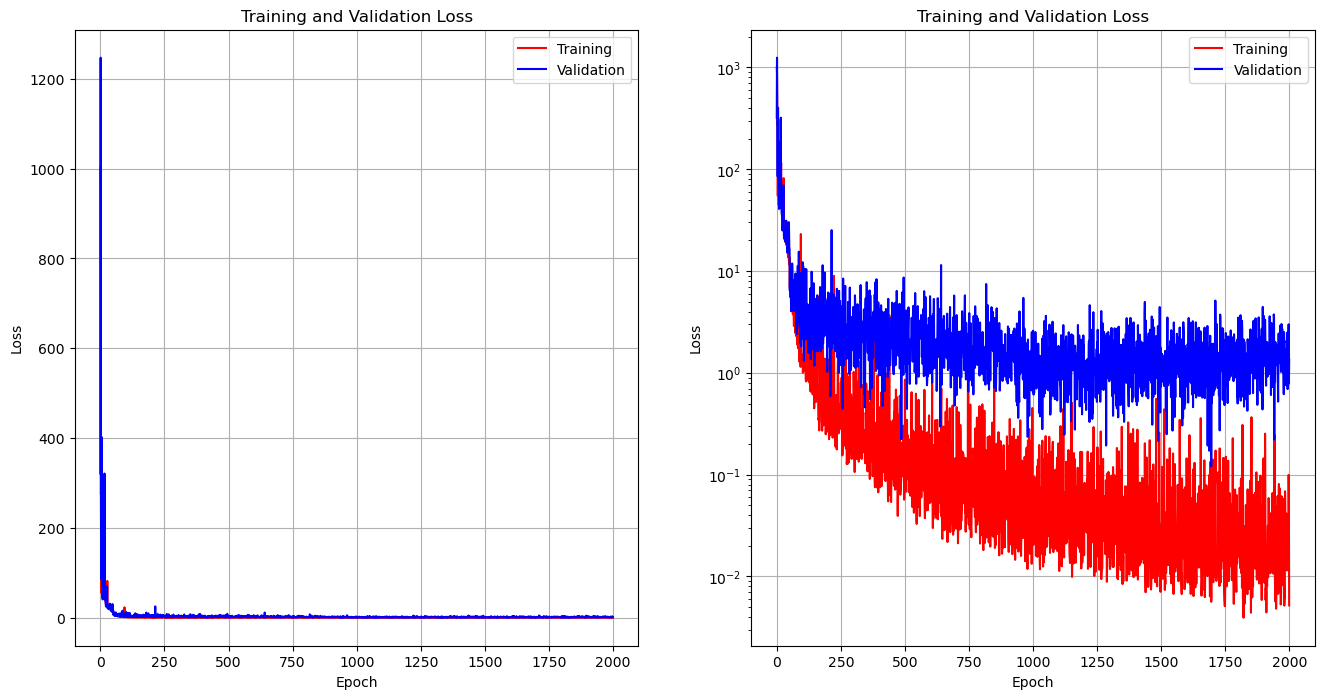

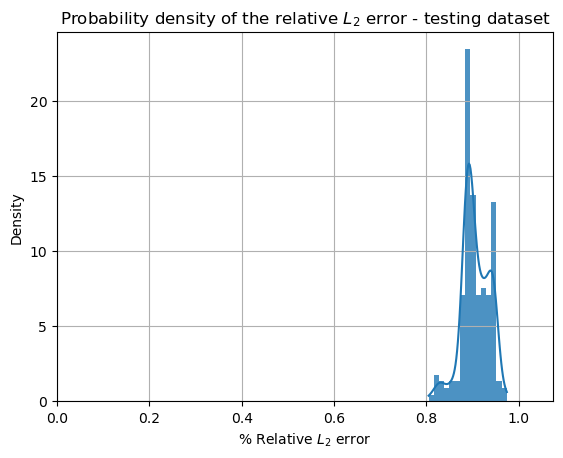

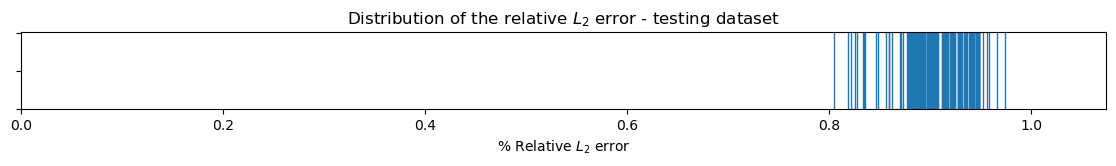

In [12]:
# train and validate model
varmion.training_validation(
    n_epochs = n_epochs, 
    pdes_per_batch = pdes_per_batch,
    verbose = True
    )


result_dict['lambda'] = varmion.lam # parameter used in the loss function for extra boundary points, 0 by default
result_dict['best_epoch'] = varmion.best_epoch # index of the epoch with lowest validation loss, we save the weights relative to this epoch
with open(save_dir + "/result_dict", "wb") as handle:
    pickle.dump(result_dict, handle)


# plot and save losses
varmion.plot_losses(save_dir= save_dir)

# compute and then plot and save the relative L^2-error on the testing dataset, 
varmion.testing(save_dir = save_dir)

# save data in the result folder
#M si potrebbe inserire dentro la classe varmion
torch.save(varmion.model.state_dict(), save_dir + '/model_weights_best.pth')
torch.save(varmion.losses, save_dir + "/losses.pt")
torch.save(varmion.val_losses, save_dir + "/val_losses.pt")
torch.save(varmion.test_error_best, save_dir + "/test_error_best.pt")
torch.save(varmion.test_abs_error_best, save_dir + "/test_abs_error_best.pt")

/tmp/ipykernel_2543223/2972321949.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loss= torch.load(weights_dir+ "/losses.pt")
/tmp/ipykernel_2543223/2972321949.py:5: Fut

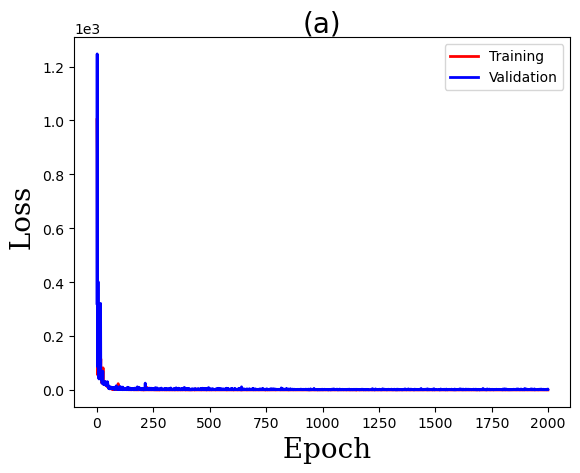

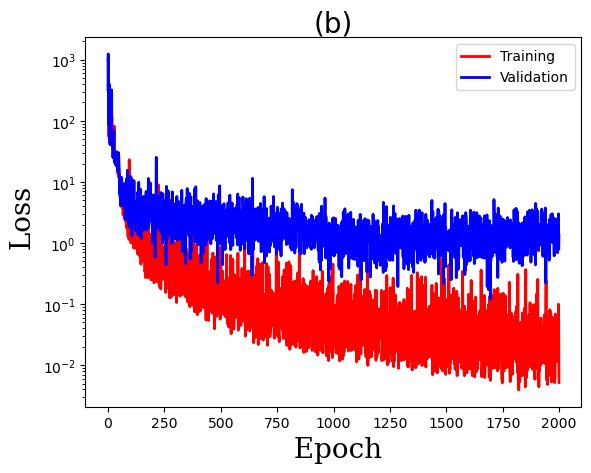

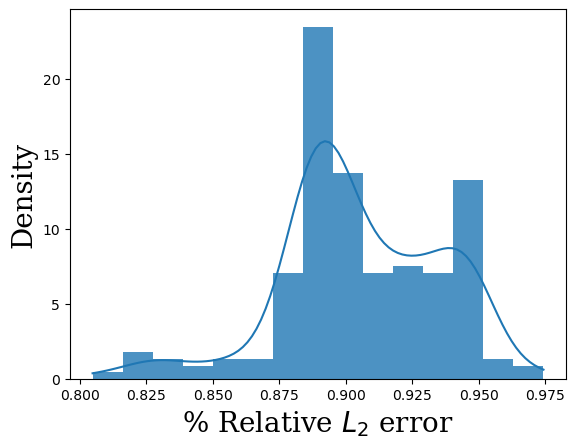

In [31]:
weights_dir = f"/home/lrinaldi/Docker_varmion/laura/fluidodinamica/Contraction_flow/results_2d_Robin_20251203_0903"
font2 = {'family':'serif','color':'black','size':20}
import torch
loss= torch.load(weights_dir+ "/losses.pt")
val= torch.load(weights_dir + "/val_losses.pt")


plt.figure()
plt.plot(  loss, '-r',  linewidth = '2', label='Training')
plt.plot(val, '-b',  linewidth = '2', label='Validation')
plt.ylabel(" Loss",fontdict = font2);
plt.xlabel(" Epoch",fontdict = font2);
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
# plt.ylim(0,3.2)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.title('(a)' ,  pad=-20, fontsize= 20);



plt.figure()
plt.semilogy(  loss, '-r',  linewidth = '2', label='Training')
plt.semilogy(val, '-b',  linewidth = '2', label='Validation')
plt.ylabel(" Loss",fontdict = font2);
plt.xlabel(" Epoch",fontdict = font2);
# plt.ylim(0,3.2)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.title('(b)' ,  pad=-20, fontsize= 20);

test_error_best_numpy= torch.load(weights_dir + "/test_error_best.pt")
err_rel = test_error_best_numpy*100


                
density = stats.gaussian_kde(err_rel)
x = np.linspace(min(err_rel), max(err_rel), 100)
                            
plt.figure()
plt.plot(x, density(x), color='C0')
plt.hist(err_rel, bins=15, density=True, color='C0', alpha=0.8)
plt.xlabel(r'% Relative $L_2$ error',fontdict = font2);
plt.ylabel('Density',fontdict = font2);

# Compare numerical solution with model prediction for a single PDE instance
## Select a specific PDE instance by index

In [13]:
font2 = {'family':'serif','color':'black','size':15}
n_p_g=325*2
gx=50
gy=10
L= 2.2
R= 0.4

In [14]:
# the index can vary between 0 and num_pdes - 1
# example: use varmion.test_data.indices[0] for an instance in the testing dataset
index = varmion.test_data.indices[0]  
t=0
print('mu=', 1/varmion.test_data[0][1], 'f=', 80*varmion.test_data[0][2])

mu= tensor(1.6434) f= tensor(44.5305)


In [15]:
pde_data = torch.utils.data.Subset(dataset, [index])

# path of the directory containing the weights to be used for the prediction
weights_dir = save_dir + '/model_weights_best.pth'

# create a model and send it to device
device = 'cpu'
print(f"{device = }")
model = HeatEquationVarMiONRobin()
model.load_state_dict(torch.load(weights_dir, weights_only = True)) ## put correct path
model.to(device)
# set to eval mode
model.eval()


# create a dataloader
loader = DataLoader(pde_data, batch_size=1)
            
# compute predictions
for j, test_data in enumerate(loader): 
            
    X = [elem.to(device) for elem in test_data[:-1]]
    y = test_data[-1]
            
    with torch.no_grad():  
        pred = model(X,  y) 
#endfor
        

device = 'cpu'


[253 254 255 256 257 258 259 263 264 265 266 267 268 269 273 274 275 276
 277 278 279 283 284 285 286 287 288 289 293 294 295 296 297 298 299 303
 304 305 306 307 308 309 313 314 315 316 317 318 319 323 324 325 326 327
 328 329 333 334 335 336 337 338 339 343 344 345 346 347 348 349 353 354
 355 356 357 358 359 363 364 365 366 367 368 369 373 374 375 376 377 378
 379 383 384 385 386 387 388 389 393 394 395 396 397 398 399 403 404 405
 406 407 408 409 413 414 415 416 417 418 419 423 424 425 426 427 428 429
 433 434 435 436 437 438 439 443 444 445 446 447 448 449 453 454 455 456
 457 458 459 463 464 465 466 467 468 469 473 474 475 476 477 478 479 483
 484 485 486 487 488 489 493 494 495 496 497 498 499]


(np.float64(1.0685714285714287),
 np.float64(2.2538775510204085),
 np.float64(0.12),
 np.float64(0.41333333333333333))

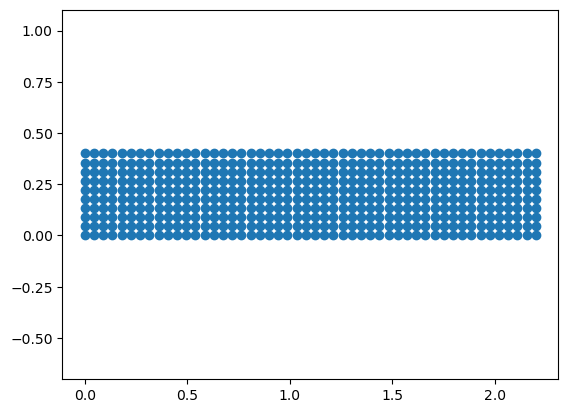

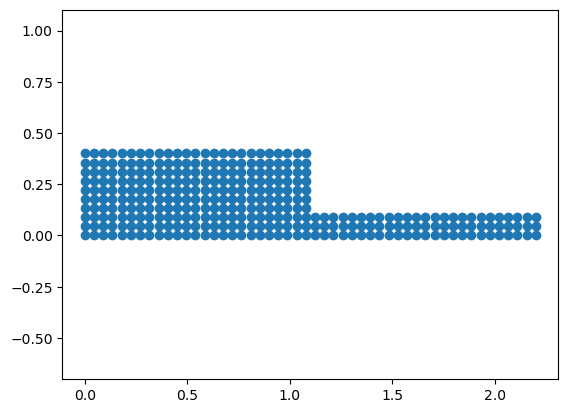

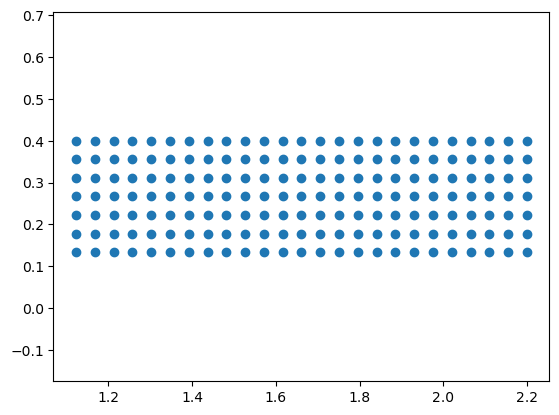

In [16]:
t=0
center = np.array([0.2, 0.2])
radius = 0.05


vy = np.linspace(0,R, gy)
vx = np.linspace(0,L ,gx)
grid_points0 = np.array([[ vx[j], vy[i], 0] for j in range(gx) for i in range(gy)])
    
 
mask = ~((grid_points0[:,0] >= L/2) & (grid_points0[:,1] >= 1*R/4))
grid_points = grid_points0[mask]    


grid_points2 = grid_points0[((grid_points0[:,0] >= L/2) & (grid_points0[:,1] >= 1*R/4))] 
#print(grid_points2)
matches = np.where(
    np.any(
        np.all(grid_points0[:, None] == grid_points2, axis=2),
        axis=1
    )
)[0]

print(matches)

plt.figure()
plt.scatter( grid_points0[:,0], grid_points0[:,1])
plt.axis('equal')     # scala proporzionale
plt.figure()
plt.scatter( grid_points[:,0], grid_points[:,1])
plt.axis('equal') 
plt.figure()
plt.scatter( grid_points2[:,0], grid_points2[:,1])
plt.axis('equal') 

/tmp/ipykernel_2543223/1997851803.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


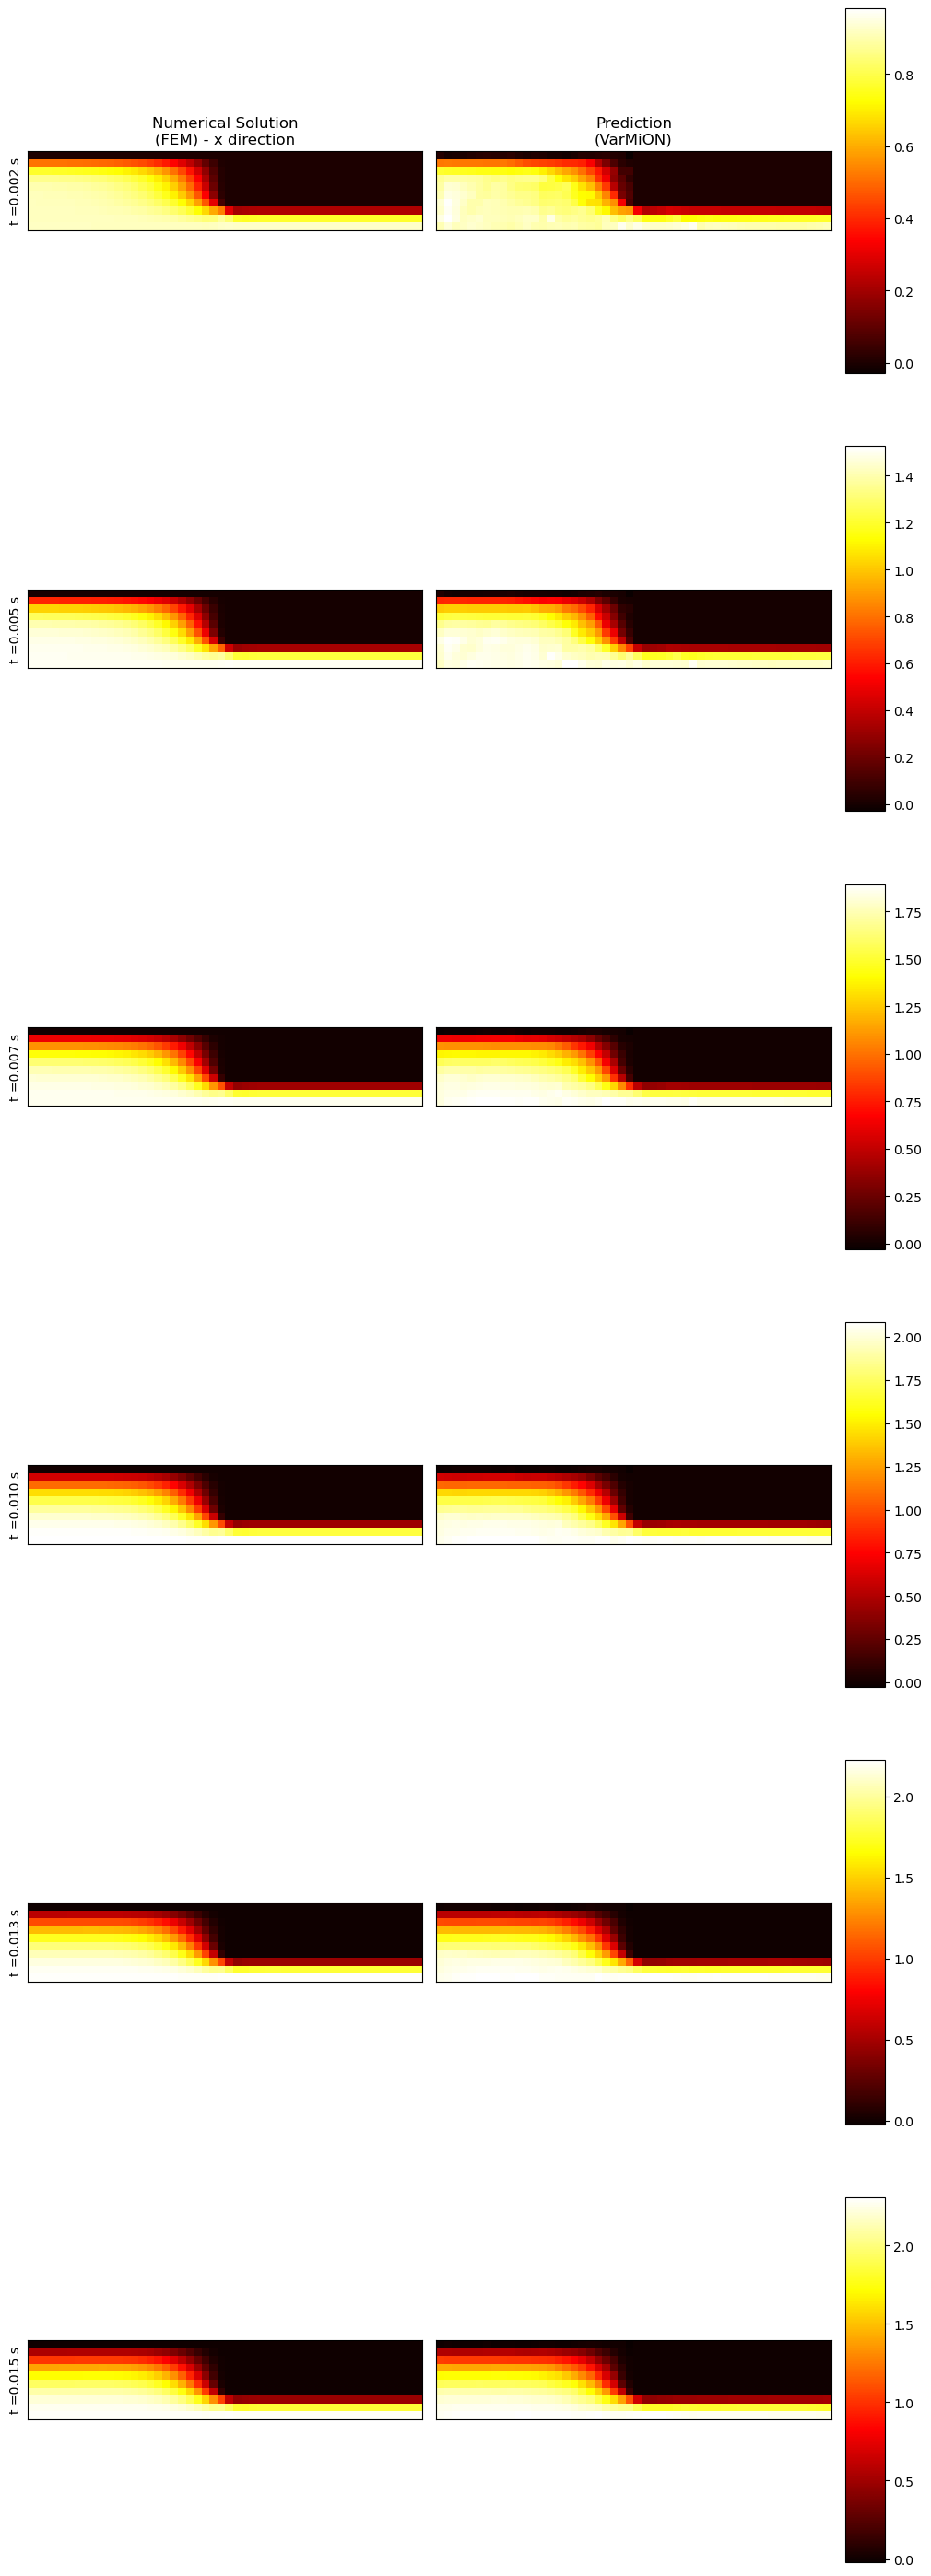

In [17]:
#n_times = len(dataset.times)-1  # Number of time steps
n_times = len(dataset.times)-15 
# Create figure
fig = plt.figure(figsize=(12, 6* n_times))  # Adjust size as needed
gs = gridspec.GridSpec(n_times, 3, width_ratios=[1, 1, 0.1], wspace=0.05)

# Create subplots for each time step
for t in range(n_times):
    array00 =dataset.data['solution'][index,t,:n_p_g:2].numpy()
    array01 =pred[0,t,:n_p_g:2].cpu().numpy()
    
    array0 = np.zeros(gy*gx)
    array1 = np.zeros(gx*gy)

    non_zero_positions = np.setdiff1d(np.arange(gx*gy), (matches%gy)*gx+(matches//gy))

    array0[non_zero_positions] = array00
    array1[non_zero_positions] = array01
    
    array0 = array0.reshape(gy,gx)
    array1 = array1.reshape(gy,gx)

    array0 = np.flipud(array0)
    array1 = np.flipud(array1)
    
    # Get global color scale limits
    vmin = min(array0.min(), array1.min())
    vmax = max(array0.max(), array1.max())
    
    ax1 = plt.subplot(gs[t, 0])
    ax2 = plt.subplot(gs[t, 1])
    cbar_ax = plt.subplot(gs[t, 2])

    im1 = ax1.imshow(array0, vmin=vmin, vmax=vmax, cmap="hot")
    im2 = ax2.imshow(array1, vmin=vmin, vmax=vmax, cmap="hot")
    
    ax1.set_ylabel(f't ={dataset.times[t+1]:.3f} s')

    ax1.set_xticks([])
    ax1.set_yticks([])
    ax2.set_xticks([])
    ax2.set_yticks([])

    if t==0:
        ax1.set_title("Numerical Solution\n(FEM) - x direction")
        ax2.set_title("Prediction\n(VarMiON)")
    
    fig.colorbar(im2, cax=cbar_ax)
    

plt.tight_layout()
plt.show()

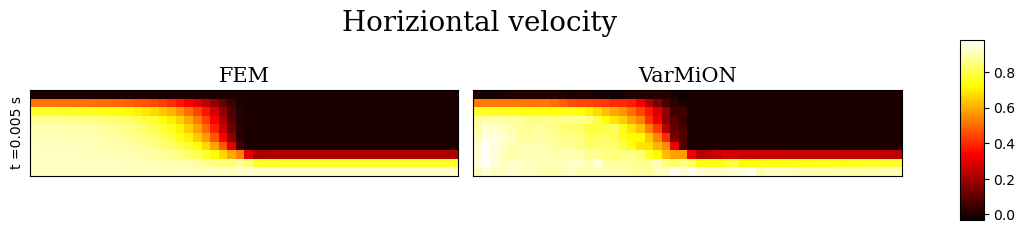

In [29]:

import matplotlib.patches as mpatches
# Create figure

fig = plt.figure(figsize=(12, 6 * n_times))  # Adjust size as needed
gs = gridspec.GridSpec(n_times, 3, width_ratios=[1, 1, 0.1], wspace=0.05)

# Titolo comune
fig.suptitle("Horiziontal velocity", font='serif', fontsize=20, x=0.5, y=0.7)
# Create subplots for each time step
for t in range(n_times):
     # if t%10==1:
        array00 =dataset.data['solution'][index,t,:n_p_g:2].numpy()
        array01 =pred[0,t,:n_p_g:2].cpu().numpy()
        
        array0 = np.zeros(gy*gx)
        array1 = np.zeros(gx*gy)
    
        non_zero_positions = np.setdiff1d(np.arange(gx*gy), (matches%gy)*gx+(matches//gy))
    
        array0[non_zero_positions] = array00
        array1[non_zero_positions] = array01
        
        array0 = array0.reshape(gy,gx)
        array1 = array1.reshape(gy,gx)
    
        array0 = np.flipud(array0)
        array1 = np.flipud(array1)
        
        # Get global color scale limits
        vmin = min(array0.min(), array1.min())
        vmax = max(array0.max(), array1.max())
        
        ax1 = plt.subplot(gs[t, 0])
        ax2 = plt.subplot(gs[t, 1])
        cbar_ax = fig.add_axes([0.9, 0.35, 0.02, 0.3])
    
        im1 = ax1.imshow(array0, vmin=vmin, vmax=vmax, cmap="hot")
        im2 = ax2.imshow(array1, vmin=vmin, vmax=vmax, cmap="hot")
        
        ax1.set_ylabel(f't ={dataset.times[t+2]:.3f} s')
    
        ax1.set_xticks([])
        ax1.set_yticks([])
        ax2.set_xticks([])
        ax2.set_yticks([])
    
        if t==0:
            ax1.set_title("FEM", fontdict = font2)
            ax2.set_title("VarMiON", fontdict = font2)
             
        fig.colorbar(im2, cax=cbar_ax)
    

plt.show()

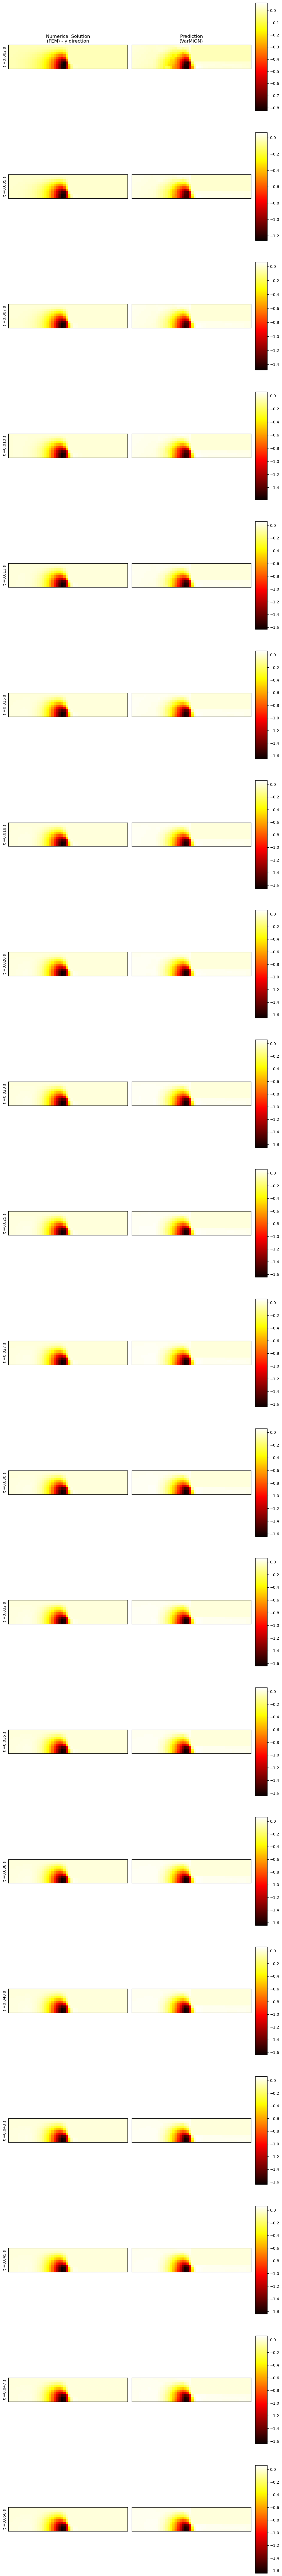

In [18]:
n_times = len(dataset.times)-1  # Number of time steps

# Create figure
fig = plt.figure(figsize=(12, 6 * n_times))  # Adjust size as needed
gs = gridspec.GridSpec(n_times, 3, width_ratios=[1, 1, 0.1], wspace=0.05)

# Create subplots for each time step
for t in range(n_times):
    array00 =dataset.data['solution'][index,t,1:n_p_g:2].numpy()
    array01 =pred[0,t,1:n_p_g:2].cpu().numpy()
    
    array0 = np.zeros(gx*gy)
    array1 = np.zeros(gx*gy)

    non_zero_positions = np.setdiff1d(np.arange(gx*gy), (matches%gy)*gx+(matches//gy))

    array0[non_zero_positions] = array00
    array1[non_zero_positions] = array01
    
    array0 = array0.reshape(gy, gx)
    array1 = array1.reshape(gy, gx)
    array0 = np.flipud(array0)
    array1 = np.flipud(array1)
    
    # Get global color scale limits
    vmin = min(array0.min(), array1.min())
    vmax = max(array0.max(), array1.max())
    
    ax1 = plt.subplot(gs[t, 0])
    ax2 = plt.subplot(gs[t, 1])
    cbar_ax = plt.subplot(gs[t, 2])

    im1 = ax1.imshow(array0, vmin=vmin, vmax=vmax, cmap="hot")
    im2 = ax2.imshow(array1, vmin=vmin, vmax=vmax, cmap="hot")
    
    ax1.set_ylabel(f't ={dataset.times[t+1]:.3f} s')

    ax1.set_xticks([])
    ax1.set_yticks([])
    ax2.set_xticks([])
    ax2.set_yticks([])
    
    


    if t==0:
        ax1.set_title("Numerical Solution\n(FEM) - y direction")
        ax2.set_title("Prediction\n(VarMiON)")
         
    fig.colorbar(im2, cax=cbar_ax)
    
plt.show()

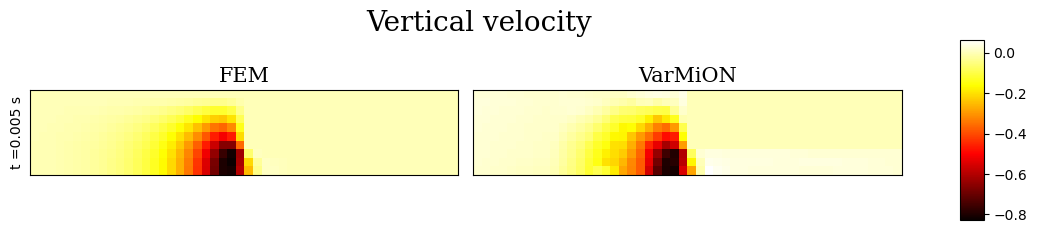

In [26]:
font2 = {'family':'serif','color':'black','size':15}
n_times = len(dataset.times)-20  # Number of time steps

import matplotlib.patches as mpatches
# Create figure

fig = plt.figure(figsize=(12, 6 * n_times))  # Adjust size as needed
gs = gridspec.GridSpec(n_times, 3, width_ratios=[1, 1, 0.1], wspace=0.05)

fig.suptitle("Vertical velocity", font='serif', fontsize=20, x=0.5, y=0.7)
# Create subplots for each time step
for t in range(n_times):
     # if t%10==1:
        array00 =dataset.data['solution'][index,t,1:n_p_g:2].numpy()
        array01 =pred[0,t,1:n_p_g:2].cpu().numpy()
        
        
        array0 = np.zeros(gy*gx)
        array1 = np.zeros(gx*gy)
        non_zero_positions = np.setdiff1d(np.arange(gx*gy), (matches%gy)*gx+(matches//gy))
    
    
        array0[non_zero_positions] = array00
        array1[non_zero_positions] = array01
        
        array0 = array0.reshape(gy,gx)
        array1 = array1.reshape(gy,gx)
    
        array0 = np.flipud(array0)
        array1 = np.flipud(array1)
        
        # Get global color scale limits
        vmin = min(array0.min(), array1.min())
        vmax = max(array0.max(), array1.max())
        
        ax1 = plt.subplot(gs[t, 0])
        ax2 = plt.subplot(gs[t, 1])
        cbar_ax = fig.add_axes([0.9, 0.35, 0.02, 0.3])
    
        im1 = ax1.imshow(array0, vmin=vmin, vmax=vmax, cmap="hot")
        im2 = ax2.imshow(array1, vmin=vmin, vmax=vmax, cmap="hot")
        
        ax1.set_ylabel(f't ={dataset.times[t+2]:.3f} s')
    
        ax1.set_xticks([])
        ax1.set_yticks([])
        ax2.set_xticks([])
        ax2.set_yticks([])
    
        if t==0:
            ax1.set_title("FEM", fontdict = font2)
            ax2.set_title("VarMiON", fontdict = font2)
             
        fig.colorbar(im2, cax=cbar_ax)
    

plt.show()

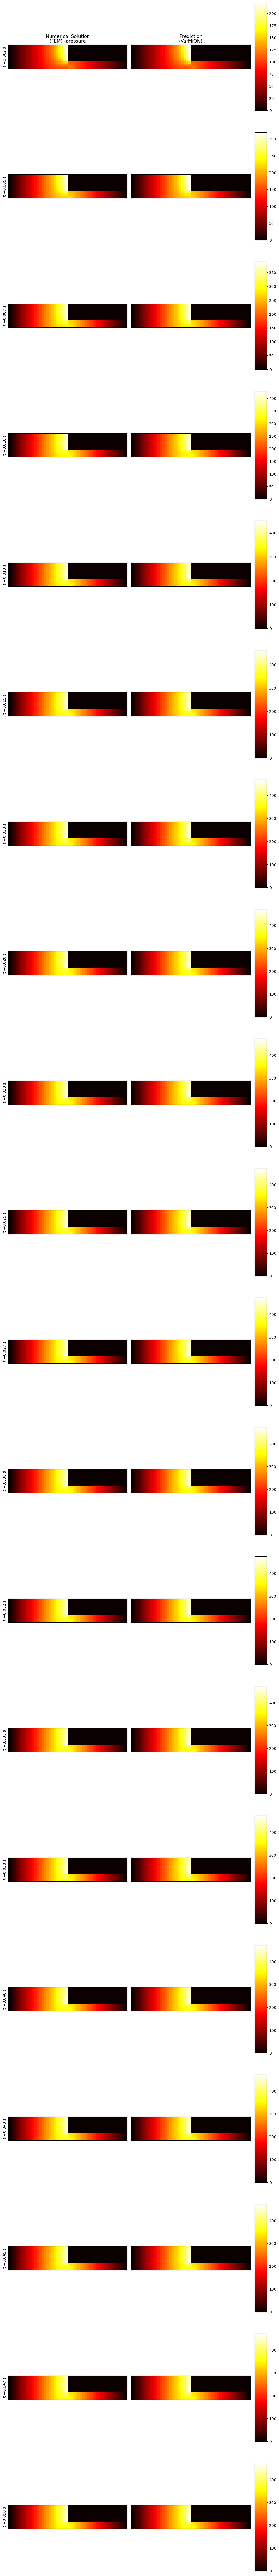

In [19]:
n_times = len(dataset.times)-1  # Number of time steps

# Create figure
fig = plt.figure(figsize=(12, 6 * n_times))  # Adjust size as needed
gs = gridspec.GridSpec(n_times, 3, width_ratios=[1, 1, 0.1], wspace=0.05)

# Create subplots for each time step
for t in range(n_times):
       
    array00 =dataset.data['solution_pressure'][index,t,::].numpy()
    array01 =pred[0,t,n_p_g:].cpu().numpy()
    
    array0 = np.zeros(gx*gy)
    array1 = np.zeros(gx*gy)
    non_zero_positions = np.setdiff1d(np.arange(gx*gy), (matches%gy)*gx+(matches//gy))

    array0[non_zero_positions] = array00
    array1[non_zero_positions] = array01
    
    array0 = array0.reshape(gy, gx)
    array1 = array1.reshape(gy, gx)
    array0 = np.flipud(array0)
    array1 = np.flipud(array1)    
    # Get global color scale limits
    vmin = min(array0.min(), array1.min())
    vmax = max(array0.max(), array1.max())
    
    ax1 = plt.subplot(gs[t, 0])
    ax2 = plt.subplot(gs[t, 1])
    cbar_ax = plt.subplot(gs[t, 2])

    im1 = ax1.imshow(array0, vmin=vmin, vmax=vmax, cmap="hot")
    im2 = ax2.imshow(array1, vmin=vmin, vmax=vmax, cmap="hot")
    
    ax1.set_ylabel(f't ={dataset.times[t+1]:.3f} s')

    ax1.set_xticks([])
    ax1.set_yticks([])
    ax2.set_xticks([])
    ax2.set_yticks([])

    if t==0:
        ax1.set_title("Numerical Solution\n(FEM) -pressure")
        ax2.set_title("Prediction\n(VarMiON)")
         
    fig.colorbar(im2, cax=cbar_ax)
    

plt.show()

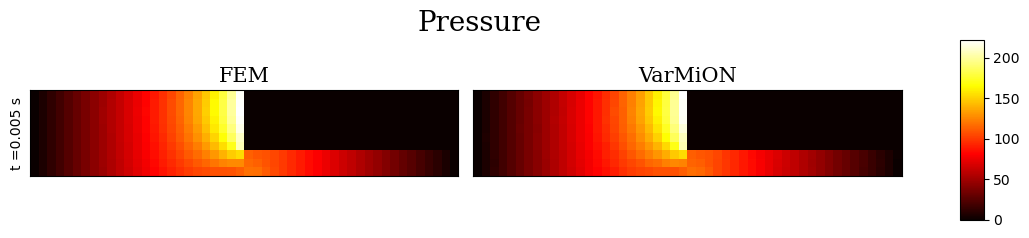

In [25]:
font2 = {'family':'serif','color':'black','size':15}
n_times = len(dataset.times)-20  # Number of time steps

import matplotlib.patches as mpatches
# Create figure

fig = plt.figure(figsize=(12, 6 * n_times))  # Adjust size as needed
gs = gridspec.GridSpec(n_times, 3, width_ratios=[1, 1, 0.1], wspace=0.05)

# Titolo comune
fig.suptitle("Pressure", font='serif', fontsize=20, x=0.5, y=0.7)
# Create subplots for each time step
for t in range(n_times):
     # if t%10==1:
        array00 =dataset.data['solution_pressure'][index,t,::].numpy()
        array01 =pred[0,t,n_p_g:].cpu().numpy()
        
        array0 = np.zeros(gy*gx)
        array1 = np.zeros(gx*gy)
    
        non_zero_positions = np.setdiff1d(np.arange(gx*gy), (matches%gy)*gx+(matches//gy))
    
    
    
        # Inserisci i valori originali nelle posizioni giuste
        array0[non_zero_positions] = array00
        array1[non_zero_positions] = array01
        
        array0 = array0.reshape(gy,gx)
        array1 = array1.reshape(gy,gx)
    
        array0 = np.flipud(array0)
        array1 = np.flipud(array1)
        
        # Get global color scale limits
        vmin = min(array0.min(), array1.min())
        vmax = max(array0.max(), array1.max())
        
        ax1 = plt.subplot(gs[t, 0])
        ax2 = plt.subplot(gs[t, 1])
        cbar_ax = fig.add_axes([0.9, 0.35, 0.02, 0.3])
    
        im1 = ax1.imshow(array0, vmin=vmin, vmax=vmax, cmap="hot")
        im2 = ax2.imshow(array1, vmin=vmin, vmax=vmax, cmap="hot")
        
        ax1.set_ylabel(f't ={dataset.times[t+2]:.3f} s')
    
        ax1.set_xticks([])
        ax1.set_yticks([])
        ax2.set_xticks([])
        ax2.set_yticks([])
    
        if t==0:
            ax1.set_title("FEM", fontdict = font2)
            ax2.set_title("VarMiON", fontdict = font2)
             
        fig.colorbar(im2, cax=cbar_ax)
    

plt.show()

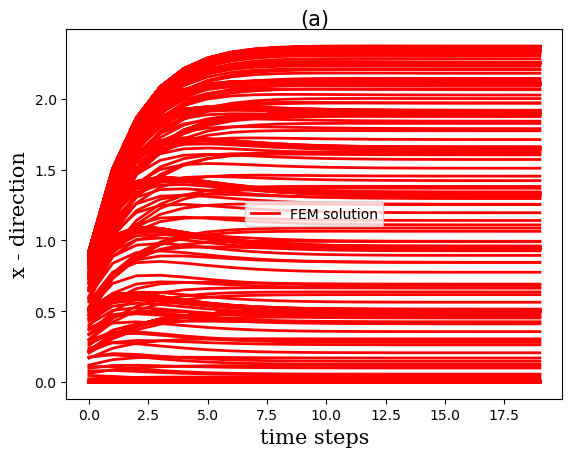

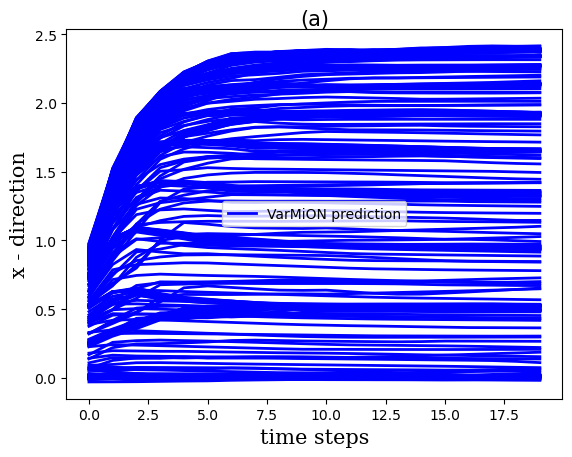

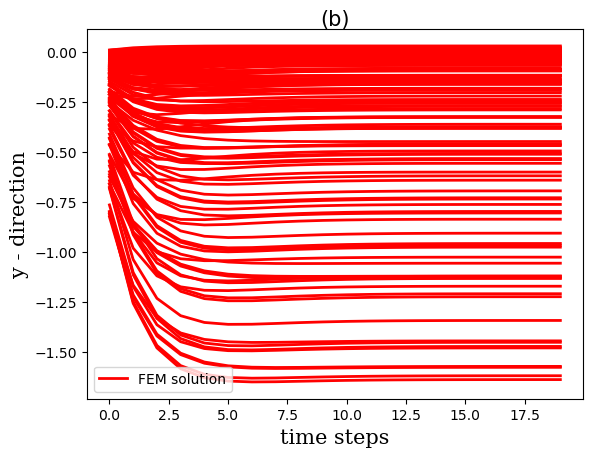

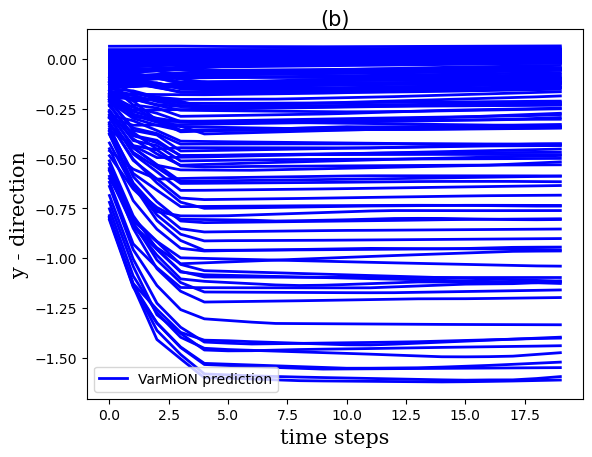

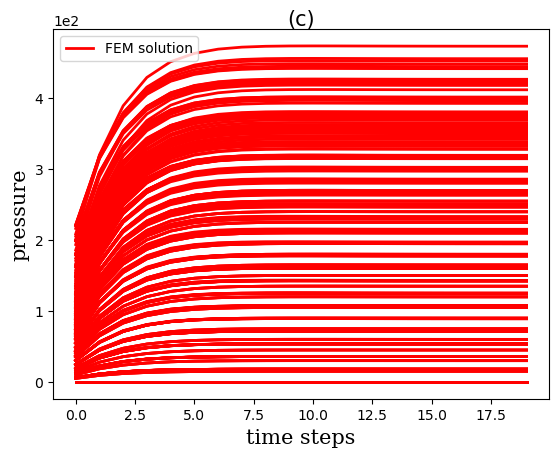

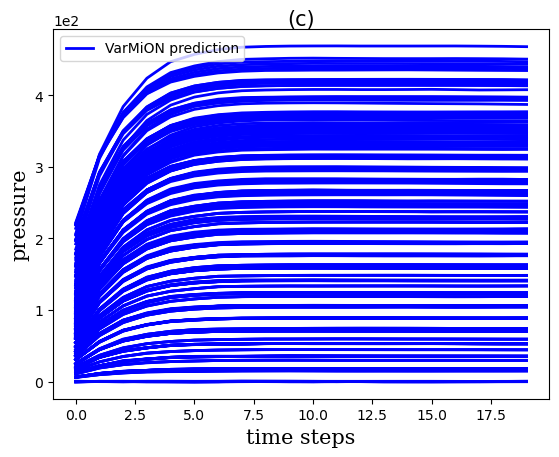

In [20]:


plt.figure()
plt.plot (dataset.data['solution'][index,:,0:n_p_g:2].numpy(), "-r" , linewidth = '2')

plt.xlabel("time steps", fontdict = font2);
plt.ylabel("x - direction",fontdict = font2);
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend(['FEM solution']);

plt.title('(a)' ,  pad=-20, fontsize= 15);

plt.figure()
plt.plot (pred[0,:,0:n_p_g:2].cpu().numpy(), "-b", linewidth = '2')
plt.xlabel("time steps", fontdict = font2);
plt.ylabel("x - direction",fontdict = font2);
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend(['VarMiON prediction']);

plt.title('(a)' ,  pad=-20, fontsize= 15);
##############################################

plt.figure()
plt.plot (dataset.data['solution'][index,:,1:n_p_g:2].numpy(), "-r" , linewidth = '2')

plt.xlabel("time steps", fontdict = font2);
plt.ylabel("y - direction",fontdict = font2);
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.legend(['FEM solution']);

plt.title('(b)' ,  pad=-20, fontsize= 15);
plt.figure()
plt.plot (pred[0,:,1:n_p_g:2].cpu().numpy(), "-b", linewidth = '2')
plt.xlabel("time steps", fontdict = font2);
plt.ylabel("y - direction",fontdict = font2);
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.legend(['VarMiON prediction']);

plt.title('(b)' ,  pad=-20, fontsize= 15);
##############################################


plt.figure()
plt.plot (dataset.data['solution_pressure'][index,:,:].numpy(), "-r" , linewidth = '2')

plt.xlabel("time steps", fontdict = font2);
plt.ylabel("pressure",fontdict = font2);
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend(['FEM solution']);

plt.title('(c)' ,  pad=-20, fontsize= 15);

plt.figure()

plt.plot (pred[0,:,n_p_g:].cpu().numpy(), "-b", linewidth = '2')
plt.xlabel("time steps", fontdict = font2);
plt.ylabel("pressure",fontdict = font2);
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend(['VarMiON prediction']);

plt.title('(c)' ,  pad=-20, fontsize= 15);

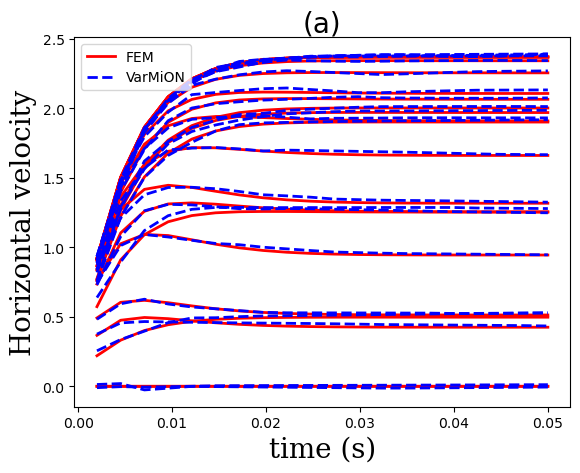

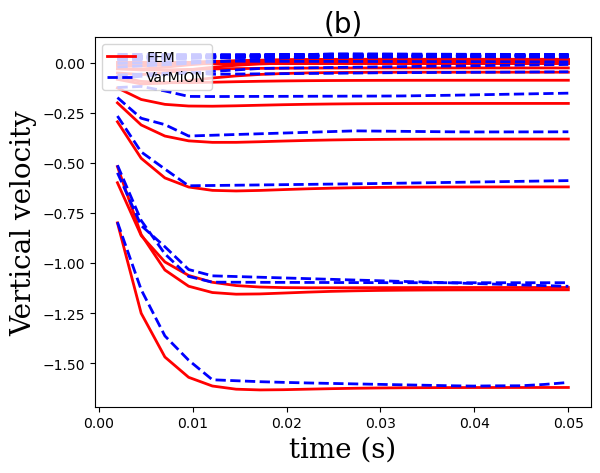

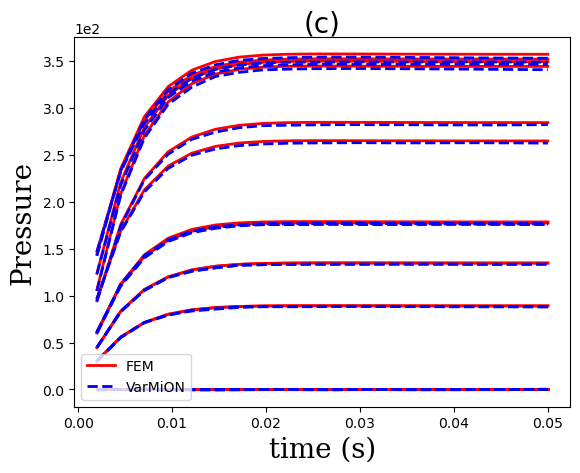

In [32]:
times= np.linspace(0.002, 0.05, 20)

plt.figure()
plt.plot (times, dataset.data['solution'][index,:,0:n_p_g:30].numpy(), "-r" , linewidth = '2', label ='FEM')
plt.plot (times, pred[0,:,0:n_p_g:30].cpu().numpy(), "--b" ,linewidth = '2', label = 'VarMiON')
plt.xlabel("time (s)", fontdict = font2);
plt.ylabel("Horizontal velocity",fontdict = font2);
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
#plt.legend();

plt.title('(a)' ,  pad=-20, fontsize= 20);
##############################################

plt.figure()
plt.plot (times, dataset.data['solution'][index,:,1:n_p_g:24].numpy(), "-r" , linewidth = '2',label ='FEM')
plt.plot (times, pred[0,:,1:n_p_g:24].cpu().numpy(), "--b", linewidth = '2', label = 'VarMiON')
plt.xlabel("time (s)", fontdict = font2);
plt.ylabel("Vertical velocity",fontdict = font2);
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc = "upper left")

plt.title('(b)' ,  pad=-20, fontsize= 20);
##############################################


plt.figure()
plt.plot (times, dataset.data['solution_pressure'][index,:,::20].numpy(), "-r" , linewidth = '2', label ='FEM')
plt.plot (times, pred[0,:,n_p_g::20].cpu().numpy(), "--b", linewidth = '2', label = 'VarMiON')
plt.xlabel("time (s)", fontdict = font2);
plt.ylabel("Pressure",fontdict = font2);
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc = "lower left")

plt.title('(c)' ,  pad=-20, fontsize= 20);